# Elliptic GNN Pipeline (Annotated)

This notebook implements graph neural network experiments on the Elliptic dataset with a strict time-forward split:

- Train: time steps 1-32
- Validation: time steps 33-37
- Test: time steps 38-42

We intentionally exclude the late period (time steps 43-49) from this experiment.

Primary objective: maximize **Validation PR-AUC (illicit class)** while tracking ROC-AUC and calibration (Brier).

We also use staged execution modes so we can verify the pipeline runs before full training:

- `smoke`: tiny/faster correctness run
- `dev`: moderate run for debugging
- `full`: production training run

In [ ]:
# Step 1: Imports, reproducibility, and run-mode configuration
# --------------------------------------------------------------
# What this step does:
#   - Imports all required libraries for data handling, PyG models, and evaluation.
#   - Sets global random seeds for reproducibility.
#   - Defines RUN_MODE to control how much data/epochs we use.
# Why this matters:
#   - We want a predictable and debuggable training pipeline before full training.
# Expected output:
#   - A short setup summary (device + selected mode).

import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Change this to "dev" or "full" when ready.
RUN_MODE = "full"

# Stage-specific settings (small -> medium -> full)
MODE_CFG = {
    "smoke": {
        "max_train_nodes": 2000,
        "epochs": 3,
        "patience": 2,
        "hidden_dim": 64,
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 5e-4,
        "loss_name": "weighted_ce",
        "focal_gamma": 2.0,
    },
    "dev": {
        "max_train_nodes": 10000,
        "epochs": 30,
        "patience": 8,
        "hidden_dim": 128,
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 5e-4,
        "loss_name": "weighted_ce",
        "focal_gamma": 2.0,
    },
    "full": {
        "max_train_nodes": None,
        "epochs": 180,
        "patience": 30,
        "hidden_dim": 128,
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 5e-4,
        "loss_name": "weighted_ce",
        "focal_gamma": 2.0,
    },
}

assert RUN_MODE in MODE_CFG, f"RUN_MODE must be one of {list(MODE_CFG.keys())}"
CFG = MODE_CFG[RUN_MODE]

print(
    f"✓ Setup complete | device={DEVICE} | run_mode={RUN_MODE} | "
    f"loss={CFG['loss_name']}"
)


c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Setup complete | device=cuda | run_mode=full | loss=weighted_ce


In [2]:
torch.cuda.is_available()

True

## Step 2 — Load raw Elliptic files and map labels

In this step, we load:

- transaction features
- class labels (`1=illicit`, `2=licit`, `unknown`)
- directed transaction edges

Then we map labels into binary targets used for supervised training:

- `y=1` for illicit
- `y=0` for licit
- unknown rows are excluded from supervised metrics/loss (but nodes remain in the graph).

In [3]:
# Step 2 code: read CSVs, standardize IDs, and build node-level table
# ------------------------------------------------------------------
# Pitfalls to avoid:
#   - Header/no-header inconsistencies
#   - txId type mismatch across files
#   - Wrong class mapping assumptions

base_path = Path("Dataset/Dataset/raw/elliptic_bitcoin_dataset")
features_file = base_path / "elliptic_txs_features.csv"
classes_file = base_path / "elliptic_txs_classes.csv"
edges_file = base_path / "elliptic_txs_edgelist.csv"

# Features file has 167 columns = [txId] + [feature_1..feature_166]
df_features = pd.read_csv(features_file, header=None)
df_features.columns = ["txId"] + [f"feature_{i}" for i in range(1, 167)]
df_features["txId"] = df_features["txId"].astype(int)

# Classes file can include a header row in some dumps
raw_classes = pd.read_csv(classes_file, header=None)
if str(raw_classes.iloc[0, 0]).lower() == "txid":
    df_classes = raw_classes.iloc[1:].reset_index(drop=True)
else:
    df_classes = raw_classes.copy()

df_classes.columns = ["txId", "class"]
df_classes["txId"] = df_classes["txId"].astype(int)

# Merge features + class labels by transaction id
df_nodes = df_features.merge(df_classes, on="txId", how="left")

# feature_1 is the temporal index (1..49)
df_nodes["time_step"] = df_nodes["feature_1"].astype(int)

# Map classes to supervised target:
# - class 1 -> illicit -> y=1
# - class 2 -> licit   -> y=0
# - unknown -> y=-1 (ignored in supervised loss/metrics)
class_numeric = pd.to_numeric(df_nodes["class"], errors="coerce")
df_nodes["y"] = np.where(class_numeric == 1, 1, np.where(class_numeric == 2, 0, -1)).astype(int)

# Read edges (txId1 -> txId2) and normalize schema
# We avoid assuming header presence by renaming after read.
df_edges = pd.read_csv(edges_file, header=None)
if df_edges.shape[1] != 2:
    raise ValueError(f"Expected 2 edge columns, got {df_edges.shape[1]}")
df_edges.columns = ["src", "dst"]

# Handle accidental header row if present
for col in ["src", "dst"]:
    df_edges[col] = pd.to_numeric(df_edges[col], errors="coerce")
df_edges = df_edges.dropna().astype({"src": int, "dst": int})

print("✓ Nodes loaded:", df_nodes.shape)
print("✓ Edges loaded:", df_edges.shape)
print("Class counts:\n", df_nodes["class"].value_counts(dropna=False).head())
print("Binary target counts (y):\n", df_nodes["y"].value_counts().sort_index())

✓ Nodes loaded: (203769, 170)
✓ Edges loaded: (234355, 2)
Class counts:
 class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
Binary target counts (y):
 y
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


## Step 3 — Build strict time-forward masks and graph tensors

Now we convert data into a PyG `Data` object and create masks:

- train: time 1-32
- val: time 33-37
- test: time 38-42

Important:
- We explicitly remove all nodes from time steps 43-49 before graph construction.
- Only labeled nodes (`y != -1`) are used in supervised loss and metrics.
- We keep unlabeled nodes in the retained window (1-42) so message passing still sees full structure.
- In `smoke` mode, we cap train labeled nodes for quick pipeline verification.

In [4]:
df_edges.sort_values(by="src")

,src,dst
229989,1076,10254
42391,2534,8939825
40660,2534,121654946
42076,2534,121674867
154373,3181,215779132
...,...,...
134041,403198336,139318803
134268,403198336,147296550
134314,403203785,264780574
135297,403244581,139456179


In [5]:
# concat str 
# df_edges.groupby("src").apply(lambda x: x["dst"].astype(str).str.cat(sep=","))

In [6]:
# Step 3 code: create node index, build edge_index, and define masks
# ------------------------------------------------------------------
# First, drop the late period entirely for this experiment.
# We only keep time steps 1..42 and remove any edges touching dropped nodes.
df_nodes = df_nodes[df_nodes["time_step"] <= 42].copy()
kept_txids = set(df_nodes["txId"].tolist())
df_edges = df_edges[df_edges["src"].isin(kept_txids) & df_edges["dst"].isin(kept_txids)].copy()

# Build a stable node index so txIds map to [0..N-1]
# The graph library needs nodes numbered 0, 1, 2, ... not raw transaction IDs
# (which are arbitrary large integers).
# We sort by txId for stability, then build a dictionary like {txId_value: row_index}
# so we can look up any transaction's position later.
df_nodes = df_nodes.sort_values("txId").reset_index(drop=True)
node_id_map = {txid: i for i, txid in enumerate(df_nodes["txId"].values)}

# Build feature matrix:
# We exclude feature_1 (time step) from model input to prevent time leakage.
feature_cols = [f"feature_{i}" for i in range(2, 167)]
x_np = df_nodes[feature_cols].to_numpy(dtype=np.float32)

# Build target vector with -1 for unlabeled nodes
y_np = df_nodes["y"].to_numpy(dtype=np.int64)

# Map raw edges to node indices and drop edges with missing endpoints
mapped_src = df_edges["src"].map(node_id_map)
mapped_dst = df_edges["dst"].map(node_id_map)
edge_mask = mapped_src.notna() & mapped_dst.notna()
edge_index_np = np.vstack([
    mapped_src[edge_mask].to_numpy(dtype=np.int64),
    mapped_dst[edge_mask].to_numpy(dtype=np.int64),
])

# Convert to torch tensors
x = torch.tensor(x_np, dtype=torch.float)
y = torch.tensor(y_np, dtype=torch.long)
edge_index = torch.tensor(edge_index_np, dtype=torch.long)

# Standardize features using only labeled train nodes
train_time_mask = (df_nodes["time_step"] >= 1) & (df_nodes["time_step"] <= 32)
labeled_mask_np = (y_np != -1)
train_labeled_mask_np = train_time_mask.values & labeled_mask_np

train_mean = x[train_labeled_mask_np].mean(dim=0, keepdim=True)
train_std = x[train_labeled_mask_np].std(dim=0, keepdim=True).clamp_min(1e-6)
x = (x - train_mean) / train_std

# Base split masks (time only)
train_mask_np = (df_nodes["time_step"].between(1, 32)).to_numpy()
val_mask_np = (df_nodes["time_step"].between(33, 37)).to_numpy()
test_mask_np = (df_nodes["time_step"].between(38, 42)).to_numpy()

# Supervised masks (must be in split and labeled)
train_eval_np = train_mask_np & labeled_mask_np
val_sup_np = val_mask_np & labeled_mask_np
test_sup_np = test_mask_np & labeled_mask_np

# Optimization mask for training loop:
# - in smoke/dev mode we may cap train nodes
# - in full mode it is identical to full train supervised mask
train_opt_np = train_eval_np.copy()
if CFG["max_train_nodes"] is not None:
    rng = np.random.default_rng(SEED)
    train_indices = np.where(train_opt_np)[0]
    sample_size = min(len(train_indices), CFG["max_train_nodes"])
    sampled = rng.choice(train_indices, size=sample_size, replace=False)
    capped_train = np.zeros_like(train_opt_np, dtype=bool)
    capped_train[sampled] = True
    train_opt_np = capped_train

# Convert masks to torch
train_sup_mask = torch.tensor(train_opt_np, dtype=torch.bool)      # used for optimization
train_eval_mask = torch.tensor(train_eval_np, dtype=torch.bool)    # used for train metrics
val_sup_mask = torch.tensor(val_sup_np, dtype=torch.bool)
test_sup_mask = torch.tensor(test_sup_np, dtype=torch.bool)

# Sanity assertions
assert not np.any(train_mask_np & val_mask_np)
assert not np.any(train_mask_np & test_mask_np)
assert not np.any(val_mask_np & test_mask_np)
assert train_sup_mask.sum().item() > 0, "No supervised train nodes for optimization"
assert train_eval_mask.sum().item() > 0, "No supervised train nodes for evaluation"
assert val_sup_mask.sum().item() > 0, "No supervised val nodes"
assert test_sup_mask.sum().item() > 0, "No supervised test nodes"

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)
data = data.to(DEVICE)

print(f"✓ Graph ready: nodes={data.num_nodes}, edges={data.num_edges}")
print(
    "Supervised nodes | "
    f"train_opt={int(train_sup_mask.sum())}, "
    f"train_eval={int(train_eval_mask.sum())}, "
    f"val={int(val_sup_mask.sum())}, test={int(test_sup_mask.sum())}"
)

✓ Graph ready: nodes=174085, edges=200696
Supervised nodes | train_opt=28938, train_eval=28938, val=4503, test=6436


In [7]:
mapped_src

1         109221
2         111874
3         109783
4         108701
5         111817
           ...  
200692     40760
200693     15240
200694     15240
200695     41453
200696     10356
Name: src, Length: 200696, dtype: int64

## Step 4 — Define metrics, losses, and training utilities

This section creates reusable utilities shared by all models:

- metric computation (PR-AUC, ROC-AUC, Brier, accuracy, precision, recall, F1)
- class-weighted loss setup for class imbalance
- optional focal loss (for harder minority-class emphasis)
- one training epoch
- one evaluation pass on any split
- one loss-only evaluation pass for best-loss tracking

This keeps comparisons fair because every architecture uses the exact same optimization and evaluation logic.

In [8]:
# Step 4 code: metrics + reusable train/eval helpers
# -------------------------------------------------

def compute_metrics(y_true, y_prob):
    """Compute binary classification metrics used throughout this project."""
    y_pred = (y_prob >= 0.5).astype(int)

    # Guard against degenerate split cases (single class present)
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        pr_auc = np.nan
        roc_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)

    return {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "brier": brier_score_loss(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def get_class_weights(y_tensor, mask_tensor):
    """Build class weights from supervised train nodes only."""
    y_train = y_tensor[mask_tensor].cpu().numpy()
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    # Standard imbalance ratio; clamp to avoid division issues.
    pos_weight = float(n_neg / max(n_pos, 1))
    return torch.tensor([1.0, pos_weight], dtype=torch.float, device=DEVICE)


def compute_supervised_loss(logits, y_true, class_weights):
    """Compute the configured supervised loss on a masked split."""
    if CFG["loss_name"] == "weighted_ce":
        return F.cross_entropy(logits, y_true, weight=class_weights)

    if CFG["loss_name"] == "focal":
        gamma = float(CFG.get("focal_gamma", 2.0))
        ce = F.cross_entropy(logits, y_true, weight=class_weights, reduction="none")
        pt = torch.exp(-ce)
        return ((1.0 - pt) ** gamma * ce).mean()

    raise ValueError(f"Unsupported loss_name: {CFG['loss_name']}")


def train_one_epoch(model, optimizer, class_weights):
    """One optimization step over the full graph using masked supervised nodes."""
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    loss = compute_supervised_loss(logits[train_sup_mask], data.y[train_sup_mask], class_weights)

    loss.backward()
    optimizer.step()
    return float(loss.item())


@torch.no_grad()
def evaluate_loss(model, mask, class_weights):
    """Evaluate supervised loss only on a split mask."""
    model.eval()
    logits = model(data.x, data.edge_index)
    loss = compute_supervised_loss(logits[mask], data.y[mask], class_weights)
    return float(loss.item())


@torch.no_grad()
def evaluate_split(model, mask):
    """Evaluate model on any supervised split mask."""
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 1]

    y_true = data.y[mask].cpu().numpy()
    y_prob = probs[mask].cpu().numpy()
    return compute_metrics(y_true, y_prob)


@torch.no_grad()
def get_split_preds(model, mask):
    """Return raw (y_true, y_prob) arrays for a supervised split mask.

    Unlike evaluate_split(), which aggregates everything into scalar metrics,
    this returns the full arrays so callers can sweep classification thresholds
    and build complete PR / ROC curves via sklearn.
    """
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 1]
    return data.y[mask].cpu().numpy(), probs[mask].cpu().numpy()


print("✓ Training utilities ready")


✓ Training utilities ready


## Step 5 — Define focused neural architectures (GraphSAGE + feature-only baselines)

We now focus on the model families that have shown the most promise on this split:

- input: `x`, `edge_index`
- output: class logits for each node (2 classes)

Model intuition:

- **GraphSAGE / GraphSAGE-Max / GraphSAGE-JK**: graph-aware models that keep neighborhood aggregation but vary how neighbor signal is pooled and how multi-hop information is combined.
- **GraphSAGE-Wide / GraphSAGE-JK-Wide**: higher-capacity versions of the strongest graph family.
- **MLP-Residual / MLP-LayerNorm**: feature-only deep tabular baselines to test how much predictive signal is in node attributes alone and whether LayerNorm is more stable than BatchNorm on this full-graph setup.

We intentionally remove the weaker GCN, GAT, and APPNP baselines from the active search so training budget stays concentrated on the most promising directions.

In [ ]:
# Step 5 code: model definitions
# ------------------------------


class ResidualSAGEBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5, aggr="mean"):
        super().__init__()
        self.conv = SAGEConv(in_dim, out_dim, aggr=aggr)
        self.norm = nn.LayerNorm(out_dim)
        self.res_proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.dropout = dropout

    def forward(self, x, edge_index):
        residual = self.res_proj(x)
        x = self.conv(x, edge_index)
        x = self.norm(x)
        x = F.relu(x + residual)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SAGENet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_layers=2, dropout=0.5, aggr="mean"):
        super().__init__()
        assert num_layers >= 2
        self.blocks = nn.ModuleList()
        self.blocks.append(ResidualSAGEBlock(in_dim, hidden_dim, dropout=dropout, aggr=aggr))
        for _ in range(num_layers - 2):
            self.blocks.append(ResidualSAGEBlock(hidden_dim, hidden_dim, dropout=dropout, aggr=aggr))
        self.head = nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index):
        for block in self.blocks:
            x = block(x, edge_index)
        x = self.head(x)
        return x


class SAGEJKNet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_layers=2, dropout=0.5, aggr="mean"):
        super().__init__()
        assert num_layers >= 2
        self.blocks = nn.ModuleList()
        self.blocks.append(ResidualSAGEBlock(in_dim, hidden_dim, dropout=dropout, aggr=aggr))
        for _ in range(num_layers - 2):
            self.blocks.append(ResidualSAGEBlock(hidden_dim, hidden_dim, dropout=dropout, aggr=aggr))
        self.dropout = dropout
        self.head = nn.Linear(hidden_dim * (num_layers - 1), 2)

    def forward(self, x, edge_index):
        hidden_states = []
        for block in self.blocks:
            x = block(x, edge_index)
            hidden_states.append(x)
        x = torch.cat(hidden_states, dim=1)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.head(x)
        return x


class ResidualMLPBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.dropout = dropout

    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.gelu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.fc2(x)
        x = self.bn2(x)
        x = x + residual
        x = F.gelu(x)
        return x


class MLPResidualNet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_layers=2, dropout=0.5):
        super().__init__()
        assert num_layers >= 2
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_bn = nn.BatchNorm1d(hidden_dim)
        self.blocks = nn.ModuleList(
            [ResidualMLPBlock(hidden_dim, dropout=dropout) for _ in range(num_layers - 1)]
        )
        self.head = nn.Linear(hidden_dim, 2)
        self.dropout = dropout

    def forward(self, x, _edge_index=None):
        _ = _edge_index
        x = self.input_proj(x)
        x = self.input_bn(x)
        x = F.gelu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        for block in self.blocks:
            x = block(x)

        x = self.head(x)
        return x


class LayerNormMLPBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.dropout = dropout

    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.gelu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.fc2(x)
        x = self.ln2(x)
        x = x + residual
        x = F.gelu(x)
        return x


class MLPLayerNormNet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_layers=2, dropout=0.5):
        super().__init__()
        assert num_layers >= 2
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_ln = nn.LayerNorm(hidden_dim)
        self.blocks = nn.ModuleList(
            [LayerNormMLPBlock(hidden_dim, dropout=dropout) for _ in range(num_layers - 1)]
        )
        self.head = nn.Linear(hidden_dim, 2)
        self.dropout = dropout

    def forward(self, x, _edge_index=None):
        _ = _edge_index
        x = self.input_proj(x)
        x = self.input_ln(x)
        x = F.gelu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        for block in self.blocks:
            x = block(x)

        x = self.head(x)
        return x


print("✓ GraphSAGE, GraphSAGE-Max, GraphSAGE-JK, GraphSAGE-Wide, GraphSAGE-JK-Wide, MLP-Residual, and MLP-LayerNorm definitions ready")


✓ GCN, GraphSAGE, GraphSAGE-Max, GraphSAGE-JK, GAT, MLP-Residual, and APPNP definitions ready


## Step 6 — Training runner, early stopping, and focused experiments

This step executes model training with:

- class-weighted or focal supervised loss from train split
- early stopping on validation PR-AUC
- full metric report on train/val/test
- best-loss diagnostics (`best_train_loss`, `best_val_loss`, `final_*_loss`)

We now spend the training budget only on the strongest model families: GraphSAGE variants and feature-only MLP variants.

We also allow longer `full` runs so promising models have more room to converge before we compare them.

In [ ]:
# Step 6 code: experiment runner + initial benchmark + depth ablation
# ------------------------------------------------------------------


def build_model(model_name, in_dim, hidden_dim, num_layers, dropout):
    if model_name == "GraphSAGE":
        return SAGENet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, aggr="mean"
        ).to(DEVICE)
    if model_name == "GraphSAGE-Max":
        return SAGENet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, aggr="max"
        ).to(DEVICE)
    if model_name == "GraphSAGE-JK":
        return SAGEJKNet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, aggr="mean"
        ).to(DEVICE)
    if model_name == "GraphSAGE-Wide":
        return SAGENet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, aggr="mean"
        ).to(DEVICE)
    if model_name == "GraphSAGE-JK-Wide":
        return SAGEJKNet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, aggr="mean"
        ).to(DEVICE)
    if model_name == "MLP-Residual":
        return MLPResidualNet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout
        ).to(DEVICE)
    if model_name == "MLP-LayerNorm":
        return MLPLayerNormNet(
            in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout
        ).to(DEVICE)
    raise ValueError(f"Unknown model_name: {model_name}")


def run_experiment(
    model_name, num_layers=2, hidden_dim=None, dropout=None, lr=None, weight_decay=None, store_model=False
):
    # Fill defaults from selected run-mode
    hidden_dim = CFG["hidden_dim"] if hidden_dim is None else hidden_dim
    dropout = CFG["dropout"] if dropout is None else dropout
    lr = CFG["lr"] if lr is None else lr
    weight_decay = CFG["weight_decay"] if weight_decay is None else weight_decay

    model = build_model(
        model_name, data.num_node_features, hidden_dim, num_layers, dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # IMPORTANT: class weights from full train-eval mask, not capped optimization subset
    class_weights = get_class_weights(data.y, train_eval_mask)

    best_state = None
    best_val = -np.inf
    best_epoch = -1
    best_train_loss = np.nan
    best_val_loss = np.nan
    final_train_loss = np.nan
    final_val_loss = np.nan
    patience_counter = 0

    for epoch in range(1, CFG["epochs"] + 1):
        train_loss = train_one_epoch(model, optimizer, class_weights)
        val_loss = evaluate_loss(model, val_sup_mask, class_weights)
        val_metrics = evaluate_split(model, val_sup_mask)

        final_train_loss = train_loss
        final_val_loss = val_loss

        # Early stopping on primary metric (val PR-AUC)
        val_pr = val_metrics["pr_auc"]
        if np.isnan(val_pr):
            val_pr = -np.inf

        if val_pr > best_val:
            best_val = val_pr
            best_epoch = epoch
            best_train_loss = train_loss
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CFG["patience"]:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_metrics = evaluate_split(model, train_eval_mask)
    val_metrics = evaluate_split(model, val_sup_mask)
    test_metrics = evaluate_split(model, test_sup_mask)

    out = {
        "model": model_name,
        "layers": num_layers,
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "loss_name": CFG["loss_name"],
        "focal_gamma": CFG.get("focal_gamma", np.nan),
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "train_pr_auc": train_metrics["pr_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "train_brier": train_metrics["brier"],
        "val_brier": val_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "train_acc": train_metrics["accuracy"],
        "val_acc": val_metrics["accuracy"],
        "test_acc": test_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "val_precision": val_metrics["precision"],
        "test_precision": test_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_recall": val_metrics["recall"],
        "test_recall": test_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
    }

    val_true_arr, val_prob_arr = get_split_preds(model, val_sup_mask)
    test_true_arr, test_prob_arr = get_split_preds(model, test_sup_mask)
    out["val_true"] = val_true_arr
    out["val_prob"] = val_prob_arr
    out["test_true"] = test_true_arr
    out["test_prob"] = test_prob_arr
    if store_model:
        out["trained_model"] = model

    print(
        f"{model_name} (L={num_layers}) | "
        f"Val PR-AUC={out['val_pr_auc']:.4f}, Test PR-AUC={out['test_pr_auc']:.4f}, "
        f"Val ROC={out['val_roc_auc']:.4f}, Test ROC={out['test_roc_auc']:.4f}, "
        f"BestTrainLoss={out['best_train_loss']:.4f}, BestValLoss={out['best_val_loss']:.4f}"
    )
    return out


# First benchmark pass: focused runs only on the strongest families
initial_run_specs = [
    {"model_name": "GraphSAGE", "num_layers": 2},
    {"model_name": "GraphSAGE-Max", "num_layers": 2},
    {"model_name": "GraphSAGE-JK", "num_layers": 2},
    {"model_name": "GraphSAGE-Wide", "num_layers": 2, "hidden_dim": 256, "dropout": 0.4, "lr": 3e-4},
    {"model_name": "GraphSAGE-JK-Wide", "num_layers": 2, "hidden_dim": 256, "dropout": 0.4, "lr": 3e-4},
    {"model_name": "MLP-Residual", "num_layers": 2},
    {"model_name": "MLP-LayerNorm", "num_layers": 2, "dropout": 0.4},
]

initial_results = []
for spec in initial_run_specs:
    initial_results.append(run_experiment(store_model=True, **spec))

# Depth ablation on the core models only
depth_run_specs = [
    {"model_name": "GraphSAGE"},
    {"model_name": "GraphSAGE-Max"},
    {"model_name": "GraphSAGE-JK"},
    {"model_name": "MLP-Residual"},
    {"model_name": "MLP-LayerNorm"},
]

depth_results = []
for spec in depth_run_specs:
    for depth in [2, 3, 4]:
        depth_results.append(run_experiment(num_layers=depth, store_model=False, **spec))

initial_df = pd.DataFrame(initial_results).sort_values("val_pr_auc", ascending=False)
depth_df = (
    pd.DataFrame(depth_results).sort_values(["model", "layers"]).reset_index(drop=True)
)

print("\nTop initial models by Val PR-AUC:")
print(
    initial_df[
        [
            "model",
            "layers",
            "best_epoch",
            "best_train_loss",
            "best_val_loss",
            "train_pr_auc",
            "val_pr_auc",
            "test_pr_auc",
            "train_roc_auc",
            "val_roc_auc",
            "test_roc_auc",
            "train_brier",
            "val_brier",
            "test_brier",
        ]
    ].to_string(index=False)
)


GCN (L=2) | Val PR-AUC=0.4274, Test PR-AUC=0.4721, Val ROC=0.8885, Test ROC=0.8391, BestTrainLoss=0.3108, BestValLoss=0.8323
GraphSAGE (L=2) | Val PR-AUC=0.7869, Test PR-AUC=0.7193, Val ROC=0.9643, Test ROC=0.9126, BestTrainLoss=0.1606, BestValLoss=0.2577
GraphSAGE-Max (L=2) | Val PR-AUC=0.7824, Test PR-AUC=0.6810, Val ROC=0.9611, Test ROC=0.9014, BestTrainLoss=0.2057, BestValLoss=0.3104
GraphSAGE-JK (L=2) | Val PR-AUC=0.7702, Test PR-AUC=0.6954, Val ROC=0.9639, Test ROC=0.9101, BestTrainLoss=0.2021, BestValLoss=0.2764
GAT (L=2) | Val PR-AUC=0.5658, Test PR-AUC=0.5355, Val ROC=0.9240, Test ROC=0.8694, BestTrainLoss=0.5243, BestValLoss=0.5188
MLP-Residual (L=2) | Val PR-AUC=0.7264, Test PR-AUC=0.7028, Val ROC=0.9646, Test ROC=0.8992, BestTrainLoss=0.2220, BestValLoss=0.3927
APPNP (L=2) | Val PR-AUC=0.2995, Test PR-AUC=0.2781, Val ROC=0.8505, Test ROC=0.7795, BestTrainLoss=0.4068, BestValLoss=1.3263
GCN (L=2) | Val PR-AUC=0.4292, Test PR-AUC=0.4454, Val ROC=0.8994, Test ROC=0.8408, BestT

c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be acceler

GraphSAGE-Max (L=3) | Val PR-AUC=0.6914, Test PR-AUC=0.6286, Val ROC=0.9409, Test ROC=0.8893, BestTrainLoss=0.2766, BestValLoss=0.3438


c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
c:\Users\ashis\Desktop\Finance Projects\Deep Learning project 2026\.venv\lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be acceler

GraphSAGE-Max (L=4) | Val PR-AUC=0.7052, Test PR-AUC=0.6199, Val ROC=0.9413, Test ROC=0.8807, BestTrainLoss=0.2979, BestValLoss=0.3685
GraphSAGE-JK (L=2) | Val PR-AUC=0.7516, Test PR-AUC=0.6812, Val ROC=0.9636, Test ROC=0.9038, BestTrainLoss=0.2066, BestValLoss=0.2855
GraphSAGE-JK (L=3) | Val PR-AUC=0.7228, Test PR-AUC=0.6544, Val ROC=0.9566, Test ROC=0.9018, BestTrainLoss=0.2058, BestValLoss=0.2842
GraphSAGE-JK (L=4) | Val PR-AUC=0.6520, Test PR-AUC=0.5999, Val ROC=0.9558, Test ROC=0.9032, BestTrainLoss=0.2074, BestValLoss=0.2747
GAT (L=2) | Val PR-AUC=0.4874, Test PR-AUC=0.4749, Val ROC=0.9121, Test ROC=0.8587, BestTrainLoss=0.5305, BestValLoss=0.5519
GAT (L=3) | Val PR-AUC=0.4534, Test PR-AUC=0.3904, Val ROC=0.8879, Test ROC=0.8166, BestTrainLoss=0.5957, BestValLoss=0.7175
GAT (L=4) | Val PR-AUC=0.3645, Test PR-AUC=0.3275, Val ROC=0.8645, Test ROC=0.7746, BestTrainLoss=0.7244, BestValLoss=0.9599
MLP-Residual (L=2) | Val PR-AUC=0.7424, Test PR-AUC=0.6941, Val ROC=0.9633, Test ROC=0.8

## Step 7 — Produce final comparison tables and operational diagnostics

This step produces:

1. A leaderboard table for the first architecture pass, sorted by Validation PR-AUC.
2. A depth-ablation table and transposed PR-AUC views.
3. Loss diagnostics (`best_*` and `final_*` losses) for optimization quality checks.
4. An industry-style scorecard combining ranking and operational metrics.

Validation PR-AUC remains the primary model-selection criterion.

In [11]:
# Step 7 code: tabular outputs for quick comparison and reporting
# --------------------------------------------------------------
# Note:
#   We report TRAIN + VALIDATION + TEST metrics below.
#   Validation is used for model selection; test is for final unbiased assessment.

leaderboard_cols = [
    "model", "layers", "best_epoch",
    "best_train_loss", "best_val_loss", "final_train_loss", "final_val_loss",
    "train_pr_auc", "val_pr_auc", "test_pr_auc",
    "train_roc_auc", "val_roc_auc", "test_roc_auc",
    "train_brier", "val_brier", "test_brier",
    "train_precision", "val_precision", "test_precision",
    "train_recall", "val_recall", "test_recall",
    "train_f1", "val_f1", "test_f1",
]

print("=== Neural model leaderboard (sorted by Val PR-AUC) ===")
print(initial_df[leaderboard_cols].to_string(index=False))

print("\n=== Depth ablation (model x layers) | includes TRAIN + VAL + TEST metrics ===")
print(
    depth_df[
        [
            "model", "layers", "best_epoch", "best_train_loss", "best_val_loss",
            "train_pr_auc", "val_pr_auc", "test_pr_auc",
            "train_roc_auc", "val_roc_auc", "test_roc_auc",
            "train_brier", "val_brier", "test_brier",
        ]
    ].to_string(index=False)
)

# Transposed format for easy copy/paste to docs
train_depth_pivot = depth_df.pivot(index="layers", columns="model", values="train_pr_auc")
val_depth_pivot = depth_df.pivot(index="layers", columns="model", values="val_pr_auc")
test_depth_pivot = depth_df.pivot(index="layers", columns="model", values="test_pr_auc")

print("\n=== Transposed Train PR-AUC (rows=layers, cols=models) ===")
print(train_depth_pivot.to_string())

print("\n=== Transposed Val PR-AUC (rows=layers, cols=models) ===")
print(val_depth_pivot.to_string())

print("\n=== Transposed Test PR-AUC (rows=layers, cols=models) ===")
print(test_depth_pivot.to_string())

# Industry-oriented scorecard: prioritize val PR-AUC, then test PR-AUC and calibration.
industry_scorecard = initial_df[
    [
        "model", "layers", "best_epoch",
        "val_pr_auc", "test_pr_auc", "val_roc_auc", "test_roc_auc",
        "val_brier", "test_brier",
        "val_precision", "test_precision", "val_recall", "test_recall",
        "val_f1", "test_f1",
        "best_val_loss", "best_train_loss",
    ]
].copy()
industry_scorecard["rank_val_pr_auc"] = (
    industry_scorecard["val_pr_auc"].rank(ascending=False, method="min").astype(int)
)
industry_scorecard = industry_scorecard.sort_values(
    ["val_pr_auc", "test_pr_auc"], ascending=[False, False]
).reset_index(drop=True)

print("\n=== Industry scorecard (primary sort: Val PR-AUC) ===")
print(industry_scorecard.to_string(index=False))

best_candidate = industry_scorecard.iloc[0]
print("\n=== Recommended candidate (PR-AUC-first) ===")
print(
    f"Model={best_candidate['model']} | L={int(best_candidate['layers'])} | "
    f"Val PR-AUC={best_candidate['val_pr_auc']:.4f} | Test PR-AUC={best_candidate['test_pr_auc']:.4f} | "
    f"Test ROC-AUC={best_candidate['test_roc_auc']:.4f} | Test Brier={best_candidate['test_brier']:.4f}"
)


=== Neural model leaderboard (sorted by Val PR-AUC) ===
        model  layers  best_epoch  best_train_loss  best_val_loss  final_train_loss  final_val_loss  train_pr_auc  val_pr_auc  test_pr_auc  train_roc_auc  val_roc_auc  test_roc_auc  train_brier  val_brier  test_brier  train_precision  val_precision  test_precision  train_recall  val_recall  test_recall  train_f1   val_f1  test_f1
    GraphSAGE       2         111         0.160588       0.257731          0.152697        0.251993      0.949836    0.786855     0.719288       0.989890     0.964330      0.912616     0.040754   0.090026    0.110141         0.694868       0.330233        0.369958      0.951205    0.901587     0.807284  0.803077 0.483404 0.507392
GraphSAGE-Max       2          78         0.205739       0.310399          0.178383        0.288934      0.916818    0.782375     0.681031       0.982347     0.961050      0.901437     0.058174   0.124956    0.153210         0.593464       0.265049        0.291473      0.934156  

## Optional Extension — Equal-Weight GraphSAGE + MLP Ensemble

This block evaluates a simple probability-level ensemble of the strongest graph model family and the feature-only residual MLP baseline.

Why this is useful:
- GraphSAGE captures neighborhood structure.
- MLP-Residual captures strong tabular/node-feature signal.
- Averaging their probabilities can improve robustness and sometimes lift test PR-AUC when their errors are only partially correlated.

In [12]:
# Ensemble evaluation: equal-weight GraphSAGE + MLP-Residual
# --------------------------------------------------------

@torch.no_grad()
def get_split_probs(model, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 1]
    return probs[mask].cpu().numpy()


def evaluate_ensemble(graph_model_name="GraphSAGE", feature_model_name="MLP-Residual", graph_weight=0.5):
    graph_result = next(res for res in initial_results if res["model"] == graph_model_name)
    feature_result = next(res for res in initial_results if res["model"] == feature_model_name)

    graph_model = graph_result["trained_model"]
    feature_model = feature_result["trained_model"]
    feature_weight = 1.0 - graph_weight

    ensemble_rows = []
    for split_name, mask in [("val", val_sup_mask), ("test", test_sup_mask)]:
        y_true = data.y[mask].cpu().numpy()
        graph_prob = get_split_probs(graph_model, mask)
        feature_prob = get_split_probs(feature_model, mask)
        ensemble_prob = graph_weight * graph_prob + feature_weight * feature_prob
        metrics = compute_metrics(y_true, ensemble_prob)
        ensemble_rows.append(
            {
                "model": f"Ensemble[{graph_model_name}+{feature_model_name}]",
                "split": split_name,
                "graph_weight": graph_weight,
                "pr_auc": metrics["pr_auc"],
                "roc_auc": metrics["roc_auc"],
                "brier": metrics["brier"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
            }
        )

    return pd.DataFrame(ensemble_rows)


ensemble_df = evaluate_ensemble(graph_model_name="GraphSAGE", feature_model_name="MLP-Residual", graph_weight=0.5)
print("=== Equal-weight GraphSAGE + MLP-Residual ensemble ===")
print(ensemble_df.to_string(index=False))


=== Equal-weight GraphSAGE + MLP-Residual ensemble ===
                           model split  graph_weight   pr_auc  roc_auc    brier  precision   recall       f1
Ensemble[GraphSAGE+MLP-Residual]   val           0.5 0.790237 0.967322 0.123714   0.271003 0.952381 0.421941
Ensemble[GraphSAGE+MLP-Residual]  test           0.5 0.734545 0.907428 0.153399   0.291517 0.860395 0.435484


## Saving the smoke run results

In [13]:
# from pathlib import Path
# from datetime import datetime

# ts = datetime.now().strftime("%Y%m%d_%H%M%S")
# out_dir = Path("results") / "gnn" / RUN_MODE / ts
# out_dir.mkdir(parents=True, exist_ok=True)

# initial_df.to_csv(out_dir / "initial_results.csv", index=False)
# depth_df.to_csv(out_dir / "depth_results.csv", index=False)

# train_depth_pivot.to_csv(out_dir / "train_pr_auc_pivot.csv")
# val_depth_pivot.to_csv(out_dir / "val_pr_auc_pivot.csv")
# test_depth_pivot.to_csv(out_dir / "test_pr_auc_pivot.csv")

# summary = initial_df.sort_values("val_pr_auc", ascending=False).head(1)
# summary.to_csv(out_dir / "best_model_summary.csv", index=False)

# print(f"Saved {RUN_MODE}-run artifacts to: {out_dir.resolve()}")

## Step 8 — PR and ROC Curves for Initial Architecture Benchmark

The scalar AUC values in Steps 6/7 summarize each curve as a single number, which is useful for ranking models but hides the shape of the trade-off. Here we plot the **full curves** for all models in the initial benchmark.

**Precision-Recall curve (primary):**
Each point on the curve is a `(recall, precision)` pair computed at one particular classification threshold. Moving left to right = lowering the threshold = catching more illicit transactions at the cost of more false alarms. The dashed horizontal line is the **random classifier baseline** — a model that outputs a constant score achieves precision equal to the positive class prevalence.

**ROC curve (secondary):**
Each point is a `(False Positive Rate, True Positive Rate)` pair. The diagonal is the random classifier baseline (AUC = 0.50). ROC is shown as a secondary diagnostic because class imbalance can make ROC look optimistic.

Both **validation** (steps 33-37) and **test** (steps 38-42) splits are shown. The raw probability arrays needed to sweep thresholds were collected inside `run_experiment()` in Step 6 and stored alongside scalar metrics — no re-training is required here.

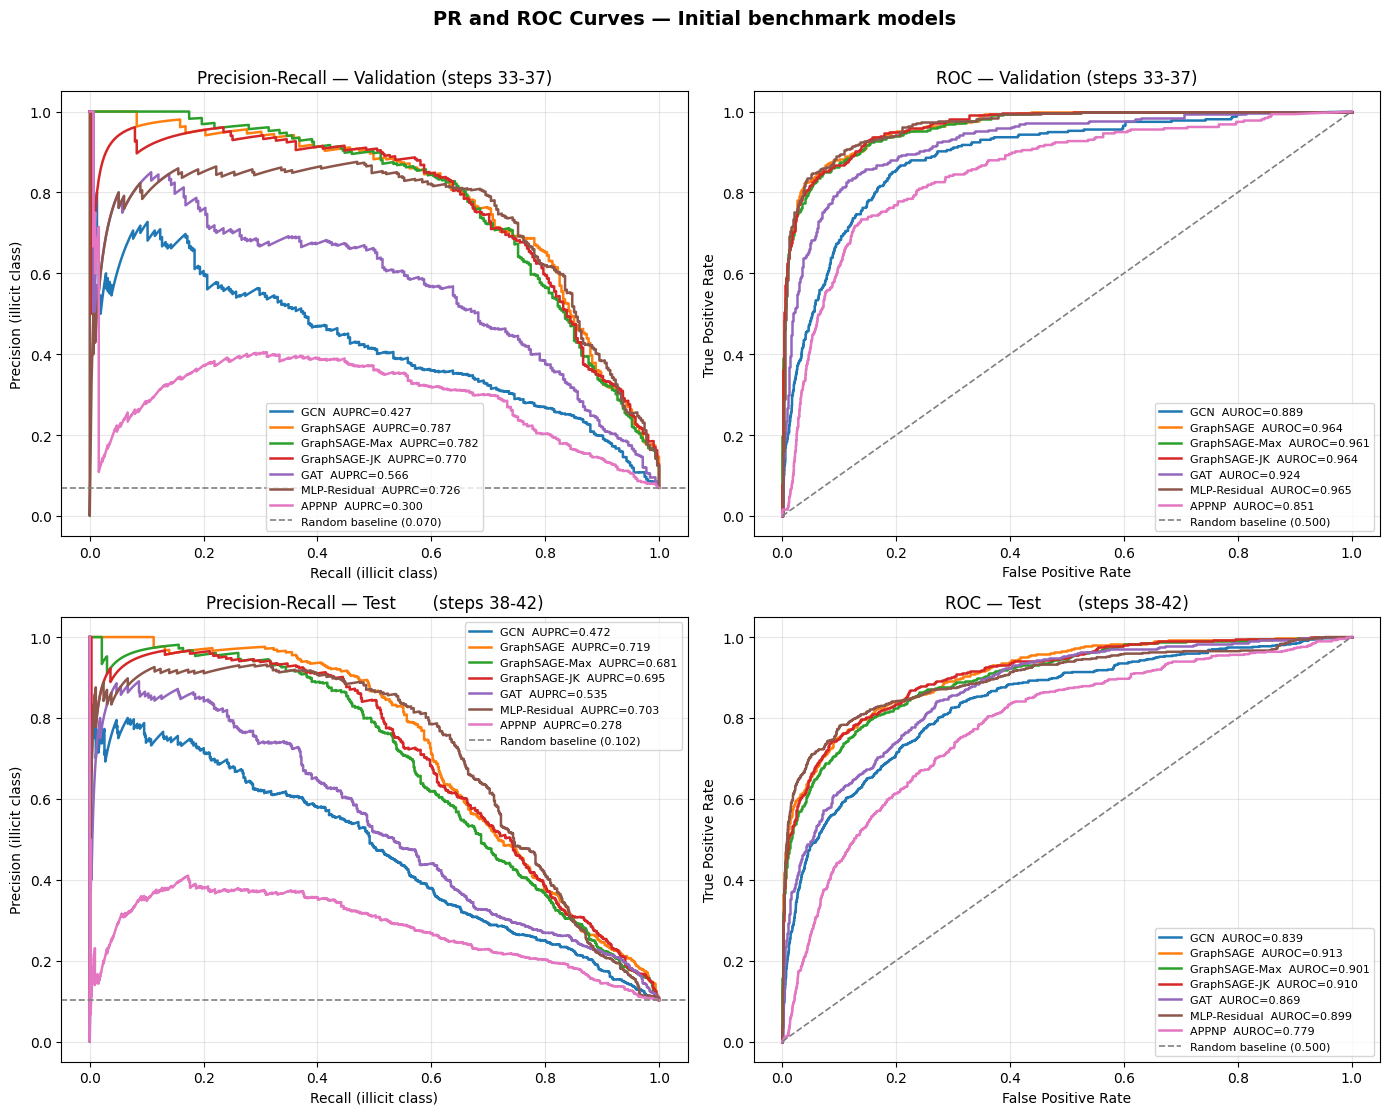

✓ Step 8 curves rendered


In [14]:
# Step 8 code: PR and ROC curves for the initial benchmark models
# -------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

model_names = [res["model"] for res in initial_results]
cmap = plt.get_cmap("tab10")
PALETTE = {m: cmap(i % 10) for i, m in enumerate(model_names)}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    "PR and ROC Curves — Initial benchmark models",
    fontsize=14, fontweight="bold", y=1.01,
)

splits = [
    ("Validation (steps 33-37)", "val_true", "val_prob", axes[0]),
    ("Test       (steps 38-42)", "test_true", "test_prob", axes[1]),
]

for split_label, true_key, prob_key, (ax_pr, ax_roc) in splits:
    split_prefix = "val" if true_key == "val_true" else "test"
    prevalence = initial_results[0][true_key].mean()

    for res in initial_results:
        model_name = res["model"]
        prec, rec, _ = precision_recall_curve(res[true_key], res[prob_key])
        auc_val = res[f"{split_prefix}_pr_auc"]
        ax_pr.plot(
            rec, prec, color=PALETTE[model_name], lw=1.8,
            label=f"{model_name}  AUPRC={auc_val:.3f}",
        )
    ax_pr.axhline(
        y=prevalence, color="grey", linestyle="--", lw=1.2,
        label=f"Random baseline ({prevalence:.3f})",
    )
    ax_pr.set_xlabel("Recall (illicit class)")
    ax_pr.set_ylabel("Precision (illicit class)")
    ax_pr.set_title(f"Precision-Recall — {split_label}")
    ax_pr.legend(fontsize=8)
    ax_pr.grid(alpha=0.3)

    for res in initial_results:
        model_name = res["model"]
        fpr, tpr, _ = roc_curve(res[true_key], res[prob_key])
        auc_val = res[f"{split_prefix}_roc_auc"]
        ax_roc.plot(
            fpr, tpr, color=PALETTE[model_name], lw=1.8,
            label=f"{model_name}  AUROC={auc_val:.3f}",
        )
    ax_roc.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1.2, label="Random baseline (0.500)")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"ROC — {split_label}")
    ax_roc.legend(fontsize=8)
    ax_roc.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Step 8 curves rendered")


## Step 9 — Industry-facing model selection summary

This section converts the experiment outputs into a concise recommendation format suitable for production review:

- primary ranking by Validation PR-AUC
- secondary checks using Test PR-AUC, Test ROC-AUC, and Test Brier
- explicit statement of top candidate and two alternatives

Use this block after Step 6/7 outputs are available.

In [15]:
# Step 9 code: compact recommendation table for production discussions
# -----------------------------------------------------------------
required_cols = [
    "model", "layers", "best_epoch",
    "val_pr_auc", "test_pr_auc", "val_roc_auc", "test_roc_auc",
    "val_brier", "test_brier",
    "val_precision", "test_precision", "val_recall", "test_recall",
    "val_f1", "test_f1",
    "best_val_loss", "best_train_loss",
]

prod_table = initial_df[required_cols].copy()
prod_table = prod_table.sort_values(["val_pr_auc", "test_pr_auc"], ascending=[False, False]).reset_index(drop=True)
prod_table["rank"] = np.arange(1, len(prod_table) + 1)

cols = [
    "rank", "model", "layers", "best_epoch",
    "val_pr_auc", "test_pr_auc", "test_roc_auc", "test_brier",
    "test_precision", "test_recall", "test_f1",
    "best_val_loss", "best_train_loss",
]

print("=== Production review table (PR-AUC-first) ===")
print(prod_table[cols].to_string(index=False))

print("\n=== Top-3 recommended candidates ===")
print(prod_table[cols].head(3).to_string(index=False))


=== Production review table (PR-AUC-first) ===
 rank         model  layers  best_epoch  val_pr_auc  test_pr_auc  test_roc_auc  test_brier  test_precision  test_recall  test_f1  best_val_loss  best_train_loss
    1     GraphSAGE       2         111    0.786855     0.719288      0.912616    0.110141        0.369958     0.807284 0.507392       0.257731         0.160588
    2 GraphSAGE-Max       2          78    0.782375     0.681031      0.901437    0.153210        0.291473     0.855842 0.434850       0.310399         0.205739
    3  GraphSAGE-JK       2         119    0.770153     0.695427      0.910142    0.124788        0.328908     0.827011 0.470639       0.276362         0.202147
    4  MLP-Residual       2          73    0.726440     0.702845      0.899166    0.225517        0.223368     0.887709 0.356925       0.392691         0.222047
    5           GAT       2         120    0.565760     0.535456      0.869429    0.271410        0.186123     0.948407 0.311177       0.518767     